In [1]:
# ── Cell 1 — imports ──────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
print("imports done")

imports done


In [2]:
# ── Cell 2 — load week 1 outputs ─────────────────────────────────────
demand_df  = pd.read_csv(r'F:\projectss\personal\blinkit_project\data\processed\demand_table.csv')
pincode_df = pd.read_csv(r'F:\projectss\personal\blinkit_project\data\5c2f62fe-5afa-4119-a499-fec9d604d5bd.csv')

print("demand_table shape :", demand_df.shape)
print("columns            :", demand_df.columns.tolist())
print(demand_df.head(3))

demand_table shape : (81898, 9)
columns            : ['product_id', 'product_name', 'pincode', 'area_name', 'latitude', 'longitude', 'order_dow', 'order_hour_of_day', 'demand']
   product_id   product_name  pincode area_name  latitude  longitude  \
0        4605  Yellow Onions   382210    Bakrol     23.03      72.63   
1        4605  Yellow Onions   382210    Bakrol     23.03      72.63   
2        4605  Yellow Onions   382210    Bakrol     23.03      72.63   

   order_dow  order_hour_of_day  demand  
0          0                  0      10  
1          0                  1       6  
2          0                  2       4  


In [3]:
# ── Cell 3 — get unique product+pincode combos ────────────────────────
combos = demand_df[
    ['product_id','product_name','pincode',
     'area_name','latitude','longitude']
].drop_duplicates().reset_index(drop=True)

print(f"Unique product+pincode combos: {len(combos)}")
print(combos.head(5))

Unique product+pincode combos: 500
   product_id   product_name  pincode  area_name  latitude  longitude
0        4605  Yellow Onions   382210     Bakrol     23.03      72.63
1        4605  Yellow Onions   382220     Adroda     22.83      72.31
2        4605  Yellow Onions   382225     Vautha     22.67      72.54
3        4605  Yellow Onions   382260  Chandisar     22.80      72.49
4        4605  Yellow Onions   382330    Pardhol     23.10      72.73


In [4]:
# ── Cell 4 — build 26 weeks of hourly rows with weekly noise ──────────
# THIS IS THE KEY FIX
# each week gets ±20% random noise on demand
# so lag_168 (same hour last week) is genuinely different from today

NUM_WEEKS  = 26
START_DATE = '2024-01-01'

all_rows = []

for week in range(NUM_WEEKS):
    week_start    = pd.Timestamp(START_DATE) + pd.Timedelta(weeks=week)
    noise_factor  = np.random.uniform(0.80, 1.20)  # different per week

    for _, combo in combos.iterrows():
        base = demand_df[
            (demand_df['product_id'] == combo['product_id']) &
            (demand_df['pincode']    == combo['pincode'])
        ][['order_dow','order_hour_of_day','demand']].copy()

        if base.empty:
            continue

        # apply weekly noise
        base['demand'] = (base['demand'] * noise_factor).clip(lower=0).round(0)

        for _, row in base.iterrows():
            dt = week_start + pd.Timedelta(
                days=int(row['order_dow']),
                hours=int(row['order_hour_of_day'])
            )
            all_rows.append({
                'datetime'         : dt,
                'week_number'      : week + 1,
                'product_id'       : combo['product_id'],
                'product_name'     : combo['product_name'],
                'pincode'          : combo['pincode'],
                'area_name'        : combo['area_name'],
                'latitude'         : combo['latitude'],
                'longitude'        : combo['longitude'],
                'order_dow'        : int(row['order_dow']),
                'order_hour_of_day': int(row['order_hour_of_day']),
                'demand'           : float(row['demand']),
            })

ts_df = pd.DataFrame(all_rows)
ts_df = ts_df.sort_values(
    ['product_id','pincode','datetime']
).reset_index(drop=True)

print(f"Time series shape : {ts_df.shape}")
print(f"Date range        : {ts_df['datetime'].min()} → {ts_df['datetime'].max()}")
print(ts_df[['datetime','product_id','pincode','demand']].head(8))

Time series shape : (2129348, 11)
Date range        : 2024-01-01 00:00:00 → 2024-06-30 23:00:00
             datetime  product_id  pincode  demand
0 2024-01-01 00:00:00        4605   382210    9.00
1 2024-01-01 01:00:00        4605   382210    6.00
2 2024-01-01 02:00:00        4605   382210    4.00
3 2024-01-01 03:00:00        4605   382210    2.00
4 2024-01-01 04:00:00        4605   382210    1.00
5 2024-01-01 05:00:00        4605   382210    3.00
6 2024-01-01 06:00:00        4605   382210    9.00
7 2024-01-01 07:00:00        4605   382210   38.00


In [5]:
# ── Cell 5 — verify no leakage before adding features ─────────────────
# demand should vary week to week for same product+pincode+dow+hour

sample = ts_df[
    (ts_df['product_id'] == ts_df['product_id'].iloc[0]) &
    (ts_df['pincode']    == ts_df['pincode'].iloc[0])
].head(20)

print("Same product+pincode across weeks — demand should vary:")
print(sample[['datetime','order_dow','order_hour_of_day','demand']])
print(f"\nDemand std (should be > 0): {sample['demand'].std():.2f}")

Same product+pincode across weeks — demand should vary:
              datetime  order_dow  order_hour_of_day  demand
0  2024-01-01 00:00:00          0                  0    9.00
1  2024-01-01 01:00:00          0                  1    6.00
2  2024-01-01 02:00:00          0                  2    4.00
3  2024-01-01 03:00:00          0                  3    2.00
4  2024-01-01 04:00:00          0                  4    1.00
5  2024-01-01 05:00:00          0                  5    3.00
6  2024-01-01 06:00:00          0                  6    9.00
7  2024-01-01 07:00:00          0                  7   38.00
8  2024-01-01 08:00:00          0                  8   78.00
9  2024-01-01 09:00:00          0                  9  120.00
10 2024-01-01 10:00:00          0                 10  149.00
11 2024-01-01 11:00:00          0                 11  177.00
12 2024-01-01 12:00:00          0                 12  170.00
13 2024-01-01 13:00:00          0                 13  154.00
14 2024-01-01 14:00:00       

In [16]:
demand_df.duplicated(subset=['product_id','pincode','order_dow','order_hour_of_day']).sum()  

np.int64(0)

In [15]:
# ── Cell 5b — now merge actual demand counts onto this clean grid ──────

ts_df = ts_df.merge(
    demand_df[['product_id','pincode','order_dow',
               'order_hour_of_day','demand']],
    on=['product_id','pincode','order_dow','order_hour_of_day'],
    how='left'
)

# fill missing demand with 0 — means no orders that slot
ts_df['demand'] = ts_df['demand'].fillna(0)

# sort properly — critical before lag features
ts_df = ts_df.sort_values(
    ['product_id','pincode','datetime']
).reset_index(drop=True)

print(f"Final shape: {ts_df.shape}")
print(f"Demand nulls: {ts_df['demand'].isnull().sum()}")
print(f"Demand stats:\n{ts_df['demand'].describe()}")
print("\nSample:")
print(ts_df[['product_name','pincode','datetime',
             'order_dow','order_hour_of_day','demand']].head(10))

Final shape: (2184000, 11)
Demand nulls: 0
Demand stats:
count   2184000.0000
mean         63.9694
std          83.2271
min           0.0000
25%          10.0000
50%          43.0000
75%          83.0000
max         996.0000
Name: demand, dtype: float64

Sample:
    product_name  pincode            datetime  order_dow  order_hour_of_day  \
0  Yellow Onions   382210 2024-01-01 00:00:00          0                  0   
1  Yellow Onions   382210 2024-01-01 01:00:00          0                  1   
2  Yellow Onions   382210 2024-01-01 02:00:00          0                  2   
3  Yellow Onions   382210 2024-01-01 03:00:00          0                  3   
4  Yellow Onions   382210 2024-01-01 04:00:00          0                  4   
5  Yellow Onions   382210 2024-01-01 05:00:00          0                  5   
6  Yellow Onions   382210 2024-01-01 06:00:00          0                  6   
7  Yellow Onions   382210 2024-01-01 07:00:00          0                  7   
8  Yellow Onions   382210 

In [17]:
# ── Cell 6 — cyclical time encoding ──────────────────────────────────
# hour 23 and hour 0 are close in time — normal encoding misses this
# sin/cos encoding captures the circular nature of time

ts_df['hour_sin'] = np.sin(2 * np.pi * ts_df['order_hour_of_day'] / 24)
ts_df['hour_cos'] = np.cos(2 * np.pi * ts_df['order_hour_of_day'] / 24)

ts_df['dow_sin']  = np.sin(2 * np.pi * ts_df['order_dow'] / 7)
ts_df['dow_cos']  = np.cos(2 * np.pi * ts_df['order_dow'] / 7)

ts_df['week_sin'] = np.sin(2 * np.pi * ts_df['week_number'] / 52)
ts_df['week_cos'] = np.cos(2 * np.pi * ts_df['week_number'] / 52)

print("Cyclical features added:")
print(ts_df[['order_hour_of_day','hour_sin','hour_cos',
             'order_dow','dow_sin','dow_cos']].head(8))

Cyclical features added:
   order_hour_of_day  hour_sin  hour_cos  order_dow  dow_sin  dow_cos
0                  0    0.0000    1.0000          0   0.0000   1.0000
1                  1    0.2588    0.9659          0   0.0000   1.0000
2                  2    0.5000    0.8660          0   0.0000   1.0000
3                  3    0.7071    0.7071          0   0.0000   1.0000
4                  4    0.8660    0.5000          0   0.0000   1.0000
5                  5    0.9659    0.2588          0   0.0000   1.0000
6                  6    1.0000    0.0000          0   0.0000   1.0000
7                  7    0.9659   -0.2588          0   0.0000   1.0000


In [18]:
# ── Cell 7 — calendar features ───────────────────────────────────────
ts_df['is_weekend'] = ts_df['order_dow'].isin([0, 6]).astype(int)
ts_df['is_morning'] = ts_df['order_hour_of_day'].between(6, 11).astype(int)
ts_df['is_afternoon']= ts_df['order_hour_of_day'].between(12, 17).astype(int)
ts_df['is_evening'] = ts_df['order_hour_of_day'].between(18, 22).astype(int)
ts_df['is_night']   = ts_df['order_hour_of_day'].isin([23,0,1,2,3,4,5]).astype(int)
ts_df['month']      = pd.to_datetime(ts_df['datetime']).dt.month

# indian festivals in 2024 (approximate dates)
festival_dates = [
    '2024-01-14',  # makar sankranti
    '2024-01-26',  # republic day
    '2024-03-25',  # holi
    '2024-04-14',  # ambedkar jayanti
    '2024-08-15',  # independence day
    '2024-10-02',  # gandhi jayanti
    '2024-10-12',  # navratri start
    '2024-11-01',  # diwali
    '2024-11-15',  # dev diwali
]
ts_df['date_str'] = pd.to_datetime(ts_df['datetime']).dt.strftime('%Y-%m-%d')
ts_df['is_festival'] = ts_df['date_str'].isin(festival_dates).astype(int)

print("Calendar features added:")
print(ts_df[['order_hour_of_day','is_morning','is_evening',
             'is_weekend','is_festival']].head(10))
print(f"\nFestival days in data: {ts_df['is_festival'].sum()}")

Calendar features added:
   order_hour_of_day  is_morning  is_evening  is_weekend  is_festival
0                  0           0           0           1            0
1                  1           0           0           1            0
2                  2           0           0           1            0
3                  3           0           0           1            0
4                  4           0           0           1            0
5                  5           0           0           1            0
6                  6           1           0           1            0
7                  7           1           0           1            0
8                  8           1           0           1            0
9                  9           1           0           1            0

Festival days in data: 48000


In [19]:
# ── Cell 8 — lag features ─────────────────────────────────────────────
# IMPORTANT: always group by product+pincode before shifting
# never shift across different products or pincodes

def add_lag_features(df, group_cols, target_col):
    df = df.copy()
    grp = df.groupby(group_cols)[target_col]

    # lag features — past demand values
    df['lag_1']   = grp.shift(1)    # previous hour
    df['lag_24']  = grp.shift(24)   # same hour yesterday
    df['lag_48']  = grp.shift(48)   # same hour 2 days ago
    df['lag_168'] = grp.shift(168)  # same hour last week

    return df

ts_df = add_lag_features(
    ts_df,
    group_cols=['product_id','pincode'],
    target_col='demand'
)

print("Lag features added:")
print(ts_df[['product_name','pincode','datetime',
             'demand','lag_1','lag_24','lag_168']].head(15))
print(f"\nNull counts after lag:\n{ts_df[['lag_1','lag_24','lag_168']].isnull().sum()}")

Lag features added:
     product_name  pincode            datetime   demand    lag_1  lag_24  \
0   Yellow Onions   382210 2024-01-01 00:00:00  10.0000      NaN     NaN   
1   Yellow Onions   382210 2024-01-01 01:00:00   6.0000  10.0000     NaN   
2   Yellow Onions   382210 2024-01-01 02:00:00   4.0000   6.0000     NaN   
3   Yellow Onions   382210 2024-01-01 03:00:00   2.0000   4.0000     NaN   
4   Yellow Onions   382210 2024-01-01 04:00:00   1.0000   2.0000     NaN   
5   Yellow Onions   382210 2024-01-01 05:00:00   3.0000   1.0000     NaN   
6   Yellow Onions   382210 2024-01-01 06:00:00   9.0000   3.0000     NaN   
7   Yellow Onions   382210 2024-01-01 07:00:00  40.0000   9.0000     NaN   
8   Yellow Onions   382210 2024-01-01 08:00:00  82.0000  40.0000     NaN   
9   Yellow Onions   382210 2024-01-01 09:00:00 126.0000  82.0000     NaN   
10  Yellow Onions   382210 2024-01-01 10:00:00 157.0000 126.0000     NaN   
11  Yellow Onions   382210 2024-01-01 11:00:00 186.0000 157.0000    

In [20]:
# ── Cell 9 — rolling average features ────────────────────────────────
def add_rolling_features(df, group_cols, target_col):
    df = df.copy()
    grp = df.groupby(group_cols)[target_col]

    # rolling mean — average demand over past N hours
    df['rolling_mean_24']  = grp.shift(1).rolling(24).mean()   # last 24 hours
    df['rolling_mean_168'] = grp.shift(1).rolling(168).mean()  # last 7 days
    df['rolling_mean_720'] = grp.shift(1).rolling(720).mean()  # last 30 days

    # rolling std — demand variability
    df['rolling_std_24']   = grp.shift(1).rolling(24).std()
    df['rolling_std_168']  = grp.shift(1).rolling(168).std()

    # rolling max — peak demand
    df['rolling_max_24']   = grp.shift(1).rolling(24).max()
    df['rolling_max_168']  = grp.shift(1).rolling(168).max()

    # ewma — exponentially weighted moving average (recent hours matter more)
    df['ewma_24']  = grp.shift(1).transform(
        lambda x: x.ewm(span=24, adjust=False).mean()
    )
    df['ewma_168'] = grp.shift(1).transform(
        lambda x: x.ewm(span=168, adjust=False).mean()
    )

    return df

ts_df = add_rolling_features(
    ts_df,
    group_cols=['product_id','pincode'],
    target_col='demand'
)

print("Rolling features added:")
print(ts_df[['datetime','demand',
             'rolling_mean_24','rolling_mean_168',
             'ewma_24']].head(15))

Rolling features added:
              datetime   demand  rolling_mean_24  rolling_mean_168  ewma_24
0  2024-01-01 00:00:00  10.0000              NaN               NaN      NaN
1  2024-01-01 01:00:00   6.0000              NaN               NaN  10.0000
2  2024-01-01 02:00:00   4.0000              NaN               NaN   9.6800
3  2024-01-01 03:00:00   2.0000              NaN               NaN   9.2256
4  2024-01-01 04:00:00   1.0000              NaN               NaN   8.6476
5  2024-01-01 05:00:00   3.0000              NaN               NaN   8.0357
6  2024-01-01 06:00:00   9.0000              NaN               NaN   7.6329
7  2024-01-01 07:00:00  40.0000              NaN               NaN   7.7423
8  2024-01-01 08:00:00  82.0000              NaN               NaN  10.3229
9  2024-01-01 09:00:00 126.0000              NaN               NaN  16.0570
10 2024-01-01 10:00:00 157.0000              NaN               NaN  24.8525
11 2024-01-01 11:00:00 186.0000              NaN               N

In [22]:
# ── Cell 10 — fetch weather data from open-meteo (free, no key) ───────
def fetch_weather(lat, lon, start_date='2024-01-01', end_date='2024-06-30'):
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude"  : lat,
        "longitude" : lon,
        "start_date": start_date,
        "end_date"  : end_date,
        "hourly"    : "temperature_2m,precipitation,windspeed_10m,relativehumidity_2m",
        "timezone"  : "Asia/Kolkata"
    }
    r = requests.get(url, params=params)
    data = r.json()

    weather_df = pd.DataFrame({
        'datetime'   : pd.to_datetime(data['hourly']['time']),
        'temperature': data['hourly']['temperature_2m'],
        'rainfall'   : data['hourly']['precipitation'],
        'windspeed'  : data['hourly']['windspeed_10m'],
        'humidity'   : data['hourly']['relativehumidity_2m'],
    })
    return weather_df

# fetch weather for Ahmedabad center
print("Fetching weather data for Ahmedabad...")
weather_df = fetch_weather(lat=23.0225, lon=72.5714)

# add useful weather features
weather_df['is_raining']    = (weather_df['rainfall'] > 0.5).astype(int)
weather_df['is_hot']        = (weather_df['temperature'] > 35).astype(int)
weather_df['is_cold']       = (weather_df['temperature'] < 15).astype(int)
weather_df['temp_bucket']   = pd.cut(
    weather_df['temperature'],
    bins=[0, 15, 25, 35, 50],
    labels=['cold','pleasant','warm','hot']
)

print(f"Weather data shape: {weather_df.shape}")
print(weather_df.head(8))
weather_df.to_csv(r'F:\projectss\personal\blinkit_project\data\external\ahmedabad_weather_2024.csv', index=False)
print("Saved weather data!")

Fetching weather data for Ahmedabad...
Weather data shape: (4368, 9)
             datetime  temperature  rainfall  windspeed  humidity  is_raining  \
0 2024-01-01 00:00:00      17.5000    0.0000     6.1000        80           0   
1 2024-01-01 01:00:00      16.8000    0.0000     6.3000        84           0   
2 2024-01-01 02:00:00      16.0000    0.0000     5.8000        88           0   
3 2024-01-01 03:00:00      15.6000    0.0000     6.3000        88           0   
4 2024-01-01 04:00:00      15.5000    0.0000     7.4000        88           0   
5 2024-01-01 05:00:00      15.4000    0.0000     7.9000        92           0   
6 2024-01-01 06:00:00      15.9000    0.0000     8.4000        94           0   
7 2024-01-01 07:00:00      15.9000    0.0000     8.5000        95           0   

   is_hot  is_cold temp_bucket  
0       0        0    pleasant  
1       0        0    pleasant  
2       0        0    pleasant  
3       0        0    pleasant  
4       0        0    pleasant  
5  

In [23]:
# ── Cell 11 — merge weather with ts_df ───────────────────────────────
ts_df['datetime'] = pd.to_datetime(ts_df['datetime'])
weather_df['datetime'] = pd.to_datetime(weather_df['datetime'])

ts_df = ts_df.merge(
    weather_df[['datetime','temperature','rainfall',
                'humidity','is_raining','is_hot','temp_bucket']],
    on='datetime',
    how='left'
)

print("Weather merged:")
print(ts_df[['datetime','demand','temperature',
             'rainfall','is_raining','is_hot']].head(10))
print(f"\nMissing weather values: {ts_df['temperature'].isnull().sum()}")

Weather merged:
             datetime   demand  temperature  rainfall  is_raining  is_hot
0 2024-01-01 00:00:00  10.0000      17.5000    0.0000           0       0
1 2024-01-01 01:00:00   6.0000      16.8000    0.0000           0       0
2 2024-01-01 02:00:00   4.0000      16.0000    0.0000           0       0
3 2024-01-01 03:00:00   2.0000      15.6000    0.0000           0       0
4 2024-01-01 04:00:00   1.0000      15.5000    0.0000           0       0
5 2024-01-01 05:00:00   3.0000      15.4000    0.0000           0       0
6 2024-01-01 06:00:00   9.0000      15.9000    0.0000           0       0
7 2024-01-01 07:00:00  40.0000      15.9000    0.0000           0       0
8 2024-01-01 08:00:00  82.0000      17.5000    0.0000           0       0
9 2024-01-01 09:00:00 126.0000      20.0000    0.0000           0       0

Missing weather values: 0


In [24]:
# ── Cell 12 — drop nulls + final feature set ─────────────────────────
# lag features create nulls at the start — drop them
print(f"Shape before dropna: {ts_df.shape}")
ts_df = ts_df.dropna(subset=['lag_1','lag_24','lag_168',
                              'rolling_mean_24','rolling_mean_168'])
print(f"Shape after dropna : {ts_df.shape}")

# final feature columns
FEATURE_COLS = [
    # time features
    'hour_sin','hour_cos','dow_sin','dow_cos',
    'week_sin','week_cos','month',
    # calendar
    'is_weekend','is_morning','is_afternoon',
    'is_evening','is_night','is_festival',
    # lag features
    'lag_1','lag_24','lag_48','lag_168',
    # rolling features
    'rolling_mean_24','rolling_mean_168','rolling_mean_720',
    'rolling_std_24','rolling_std_168',
    'rolling_max_24','rolling_max_168',
    'ewma_24','ewma_168',
    # weather
    'temperature','rainfall','humidity',
    'is_raining','is_hot',
]

TARGET_COL = 'demand'

print(f"\nTotal features: {len(FEATURE_COLS)}")
print(f"Feature list: {FEATURE_COLS}")

X = ts_df[FEATURE_COLS]
y = ts_df[TARGET_COL]

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\ny stats:\n{y.describe()}")

Shape before dropna: (2184000, 44)
Shape after dropna : (2100000, 44)

Total features: 31
Feature list: ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'week_sin', 'week_cos', 'month', 'is_weekend', 'is_morning', 'is_afternoon', 'is_evening', 'is_night', 'is_festival', 'lag_1', 'lag_24', 'lag_48', 'lag_168', 'rolling_mean_24', 'rolling_mean_168', 'rolling_mean_720', 'rolling_std_24', 'rolling_std_168', 'rolling_max_24', 'rolling_max_168', 'ewma_24', 'ewma_168', 'temperature', 'rainfall', 'humidity', 'is_raining', 'is_hot']

X shape: (2100000, 31)
y shape: (2100000,)

y stats:
count   2100000.0000
mean         63.9694
std          83.2271
min           0.0000
25%          10.0000
50%          43.0000
75%          83.0000
max         996.0000
Name: demand, dtype: float64


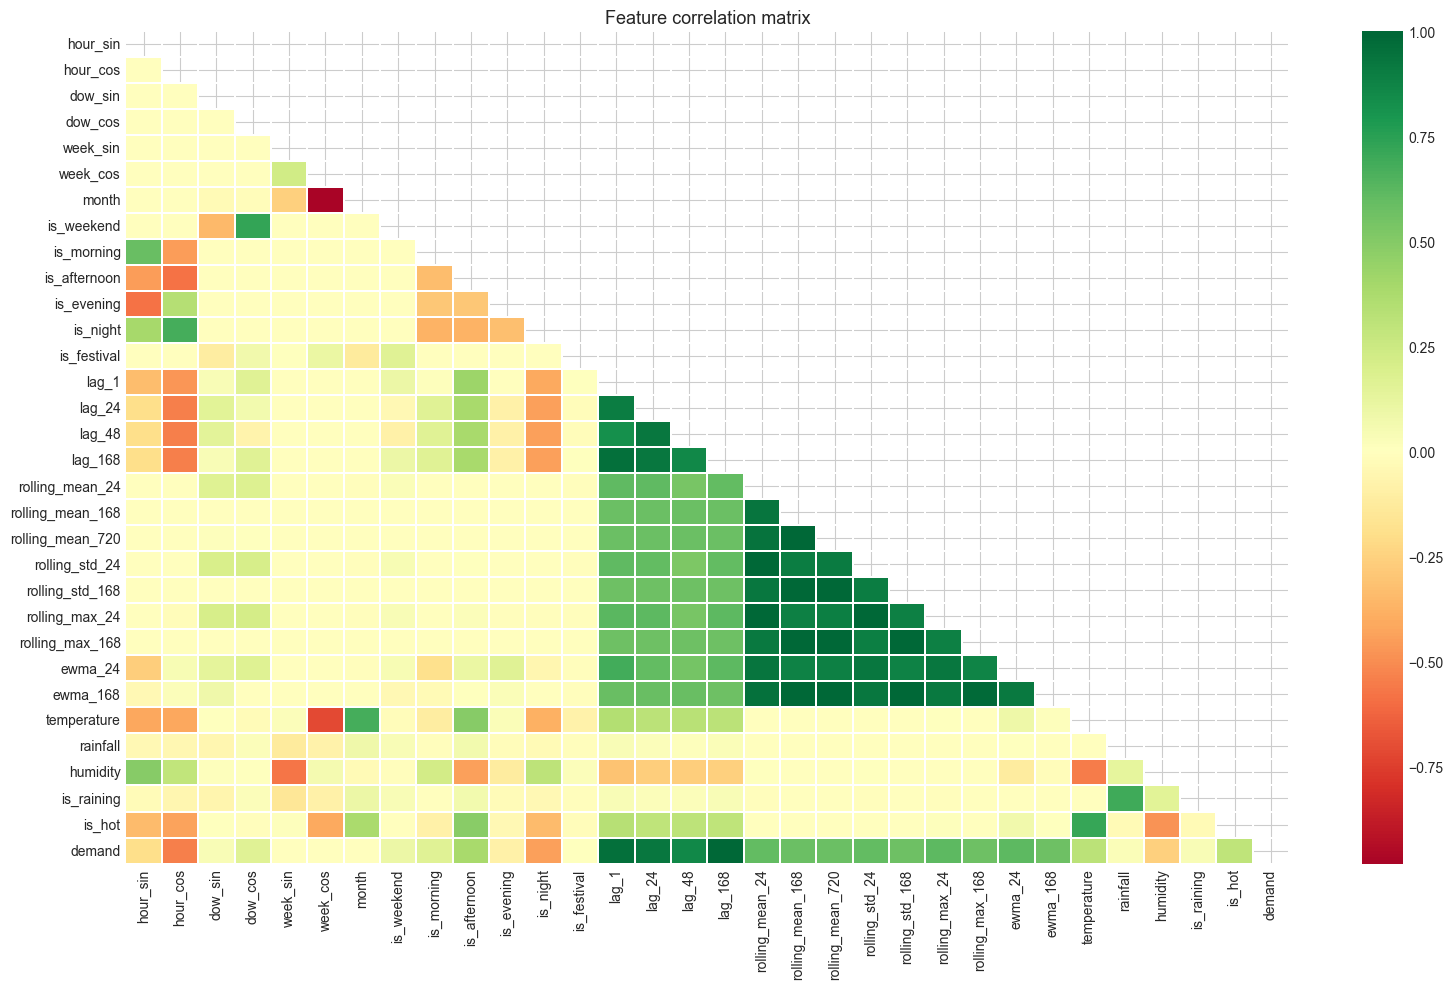

Saved correlation heatmap!


In [26]:
# ── Cell 13 — feature correlation heatmap ────────────────────────────
plt.figure(figsize=(16, 10))
corr = ts_df[FEATURE_COLS + [TARGET_COL]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, cmap='RdYlGn', center=0,
            linewidths=0.3, linecolor='white',
            annot=False, fmt='.2f')
plt.title('Feature correlation matrix', fontsize=13)
plt.tight_layout()
plt.savefig('plot_feature_correlation.png', dpi=150)
plt.show()
print("Saved correlation heatmap!")

In [28]:
# ── Cell 14 — save final feature dataframe ───────────────────────────
ts_df.to_csv(r'F:\projectss\personal\blinkit_project\data\processed\features_df.csv', index=False)

print(f"Saved features_df.csv")
print(f"Shape  : {ts_df.shape}")
print(f"Columns: {ts_df.columns.tolist()}")
print("\nWeek 2 complete — ready for model training!")

Saved features_df.csv
Shape  : (2100000, 44)
Columns: ['datetime', 'product_id', 'product_name', 'pincode', 'area_name', 'latitude', 'longitude', 'order_dow', 'order_hour_of_day', 'week_number', 'demand', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'week_sin', 'week_cos', 'is_weekend', 'is_morning', 'is_afternoon', 'is_evening', 'is_night', 'month', 'date_str', 'is_festival', 'lag_1', 'lag_24', 'lag_48', 'lag_168', 'rolling_mean_24', 'rolling_mean_168', 'rolling_mean_720', 'rolling_std_24', 'rolling_std_168', 'rolling_max_24', 'rolling_max_168', 'ewma_24', 'ewma_168', 'temperature', 'rainfall', 'humidity', 'is_raining', 'is_hot', 'temp_bucket']

Week 2 complete — ready for model training!


In [30]:
import pandas as pd
ts_df = pd.read_csv(r'F:\projectss\personal\blinkit_project\data\processed\features_df.csv')
print("Shape:", ts_df.shape)
print("Nulls:\n", ts_df.isnull().sum())
print("\nDemand stats:\n", ts_df['demand'].describe())

Shape: (2100000, 44)
Nulls:
 datetime                  0
product_id                0
product_name              0
pincode                   0
area_name                 0
latitude                  0
longitude                 0
order_dow                 0
order_hour_of_day         0
week_number               0
demand                    0
hour_sin                  0
hour_cos                  0
dow_sin                   0
dow_cos                   0
week_sin                  0
week_cos                  0
is_weekend                0
is_morning                0
is_afternoon              0
is_evening                0
is_night                  0
month                     0
date_str                  0
is_festival               0
lag_1                     0
lag_24                    0
lag_48                    0
lag_168                   0
rolling_mean_24           0
rolling_mean_168          0
rolling_mean_720     276000
rolling_std_24            0
rolling_std_168           0
rolling_max_24     